# GWR Results Visualisation

This notebook plots diagnostics from a Geographically Weighted Regression (GWR) fitted with **mgwr**:

1. **Parameter estimate maps** — one map per explanatory variable (`b_*` columns)
2. **Local R² map** — spatial variation in local model fit
3. **Standardised local residuals** — GWR residuals (z-scores)
4. **Standardised global residuals** — residuals from an equivalent global (non-spatial) model, for comparison, also z-scored

**Before running:** edit the two paths in the *Configuration* cell below to point at:
- your `.gpkg` file containing the per-location GWR output (coefficients, SEs, `Y`, `yhat`, `res`, `geometry`, ...)
- your results object/dict (pickled) containing `general_bandwidth`, `fitted_values`, `measures`, `ENP`, `global_measures`, and (if available) `localR2`

> **Note on `local R²`:** if you exported the `mgwr.gwr.GWRResults` object itself (not just a plain dict), the simplest path is `gwr_results.localR2` — that attribute exists on Gaussian-family GWR results directly. This notebook first looks for a `localR2` entry in your results dict; if it isn't there, it falls back to computing an adaptive-neighbourhood local R² manually from `Y`/`yhat` using the fitted bandwidth, which is an approximation — swap in the real attribute if you have access to it.


In [29]:
# --- Imports ---
import rdata
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import TwoSlopeNorm
from scipy.spatial import cKDTree

plt.rcParams['figure.facecolor'] = 'grey'
plt.rcParams['axes.facecolor'] = 'grey'


## Configuration

In [12]:
# --- EDIT THESE ---
GPKG_PATH = "GWNBR_Output/20260819_185720/ped_gwnbr_results.gpkg"       # per-location GWR results (points/polygons + coefficients)
RESULTS_PATH = 'GWNBR_Output/20260819_185720/gwnbr_full_result.rds'    # pickled dict/object with bandwidth, measures, ENP, global_measures, etc.

# If your model has categorical/dummy layers, drop them from significance shading below by adding to this list
EXCLUDE_FROM_COEF_PLOTS = []   # e.g. ["b_alpha"] if you don't want the dispersion parameter mapped like a covariate


## Load data

In [13]:
gdf = gpd.read_file(GPKG_PATH)
print(f"Loaded {len(gdf)} rows, CRS: {gdf.crs}")
gdf.head()


Loaded 5130 rows, CRS: EPSG:2193


c:\Users\maxwe\anaconda3\envs\geospatial_study\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: This version of GeoPackage user_version=0x000028A0 (10400, v1.4.0) on 'GWNBR_Output/20260819_185720/ped_gwnbr_results.gpkg' may only be partially supported
  return ogr_read(


,elevation_range,elevation_max,gradient,Rural_settlement_distances,Small_urban_distances,trail_density_400m,Forest_proportion,Grassland_proportion,Scrubland_proportion,Water_Bodies_proportion,...,b_Small_urban_distances,b_alpha,se_Intercept,se_closeness_centrality,se_elevation_max,se_parking_distance,se_trail_density_400m,se_Small_urban_distances,se_alpha,geometry
0,14.480400,62.909615,0.049561,947.599874,947.599874,0.024546,0.578964,0.356940,0.064096,0.000000e+00,...,-0.000268,1.972274,0.217069,34.751799,0.000336,0.000024,2.072499,0.000020,0.056824,"LINESTRING (1566602.329 5172833.423, 1566586.0..."
1,41.272972,161.233261,0.083568,0.000000,0.000000,0.027764,0.107669,0.512043,0.000000,8.881784e-15,...,-0.000260,1.981871,0.210797,34.556647,0.000333,0.000024,2.068003,0.000019,0.056449,"LINESTRING (1566699.839 5172258.991, 1566701.8..."
2,0.803947,40.802662,0.016288,697.726627,697.726627,0.031185,0.785697,0.214303,0.000000,2.087219e-14,...,-0.000267,1.973795,0.215681,34.766349,0.000336,0.000024,2.074169,0.000020,0.056891,"LINESTRING (1566455.64 5172648.094, 1566461.29..."
3,0.056458,40.673653,0.004056,871.572754,871.572754,0.033011,1.000000,0.000000,0.000000,0.000000e+00,...,-0.000268,1.973180,0.216943,34.733129,0.000336,0.000024,2.071798,0.000020,0.056702,"LINESTRING (1566556.846 5172732.852, 1566543.2..."
4,4.910843,79.592880,0.117539,706.377818,706.377818,0.042154,0.000000,0.902029,0.097971,0.000000e+00,...,-0.000267,1.974658,0.217069,34.652199,0.000335,0.000024,2.068059,0.000020,0.056372,"LINESTRING (1566745.34 5172655.19, 1566740.152..."


In [14]:
with open(RESULTS_PATH, "rb") as f:
    parsed_data = rdata.parser.parse_file(RESULTS_PATH)
    results = rdata.conversion.convert(parsed_data)

print("Top-level keys in results object:")
try:
    print(list(results.keys()))
except AttributeError:
    print("(results is not a dict — it looks like a fitted GWRResults object; adjust access below accordingly)")


Top-level keys in results object:
[np.str_('general_bandwidth'), np.str_('fitted_values'), np.str_('measures'), np.str_('ENP'), np.str_('mgwr_param_estimates'), np.str_('alpha_level_5_pct'), np.str_('t_critical'), np.str_('mgwr_se'), np.str_('global_param_estimates'), np.str_('t_test_dfs'), np.str_('global_measures')]


c:\Users\maxwe\anaconda3\envs\geospatial_study\Lib\site-packages\rdata\conversion\_conversion.py:918: UserWarning: Missing constructor for R class "mgwnbr_model". The underlying R object is returned instead.
  warnings.warn(


## Identify parameter columns

We pull the `b_*` / `se_*` pairs straight from the GeoDataFrame columns rather than hardcoding variable
names, so this stays correct if the model specification changes.


In [15]:
b_cols = [c for c in gdf.columns if c.startswith("b_")]
se_cols = [c for c in gdf.columns if c.startswith("se_")]

# pair them up by variable name
param_names = [c[2:] for c in b_cols]
missing_se = [p for p in param_names if f"se_{p}" not in gdf.columns]
if missing_se:
    print("Warning — no matching se_ column for:", missing_se)

param_names = [p for p in param_names if f"b_{p}" not in EXCLUDE_FROM_COEF_PLOTS]
print(f"Found {len(param_names)} parameters:")
param_names


Found 7 parameters:


['Intercept',
 'closeness_centrality',
 'elevation_max',
 'parking_distance',
 'trail_density_400m',
 'Small_urban_distances',
 'alpha']

## 1. Parameter estimate maps

Each panel shows the local coefficient for one explanatory variable, on a diverging colour scale
centred at zero (blue = negative effect, red = positive effect) so the sign and relative strength
of the local relationship is easy to read at a glance.


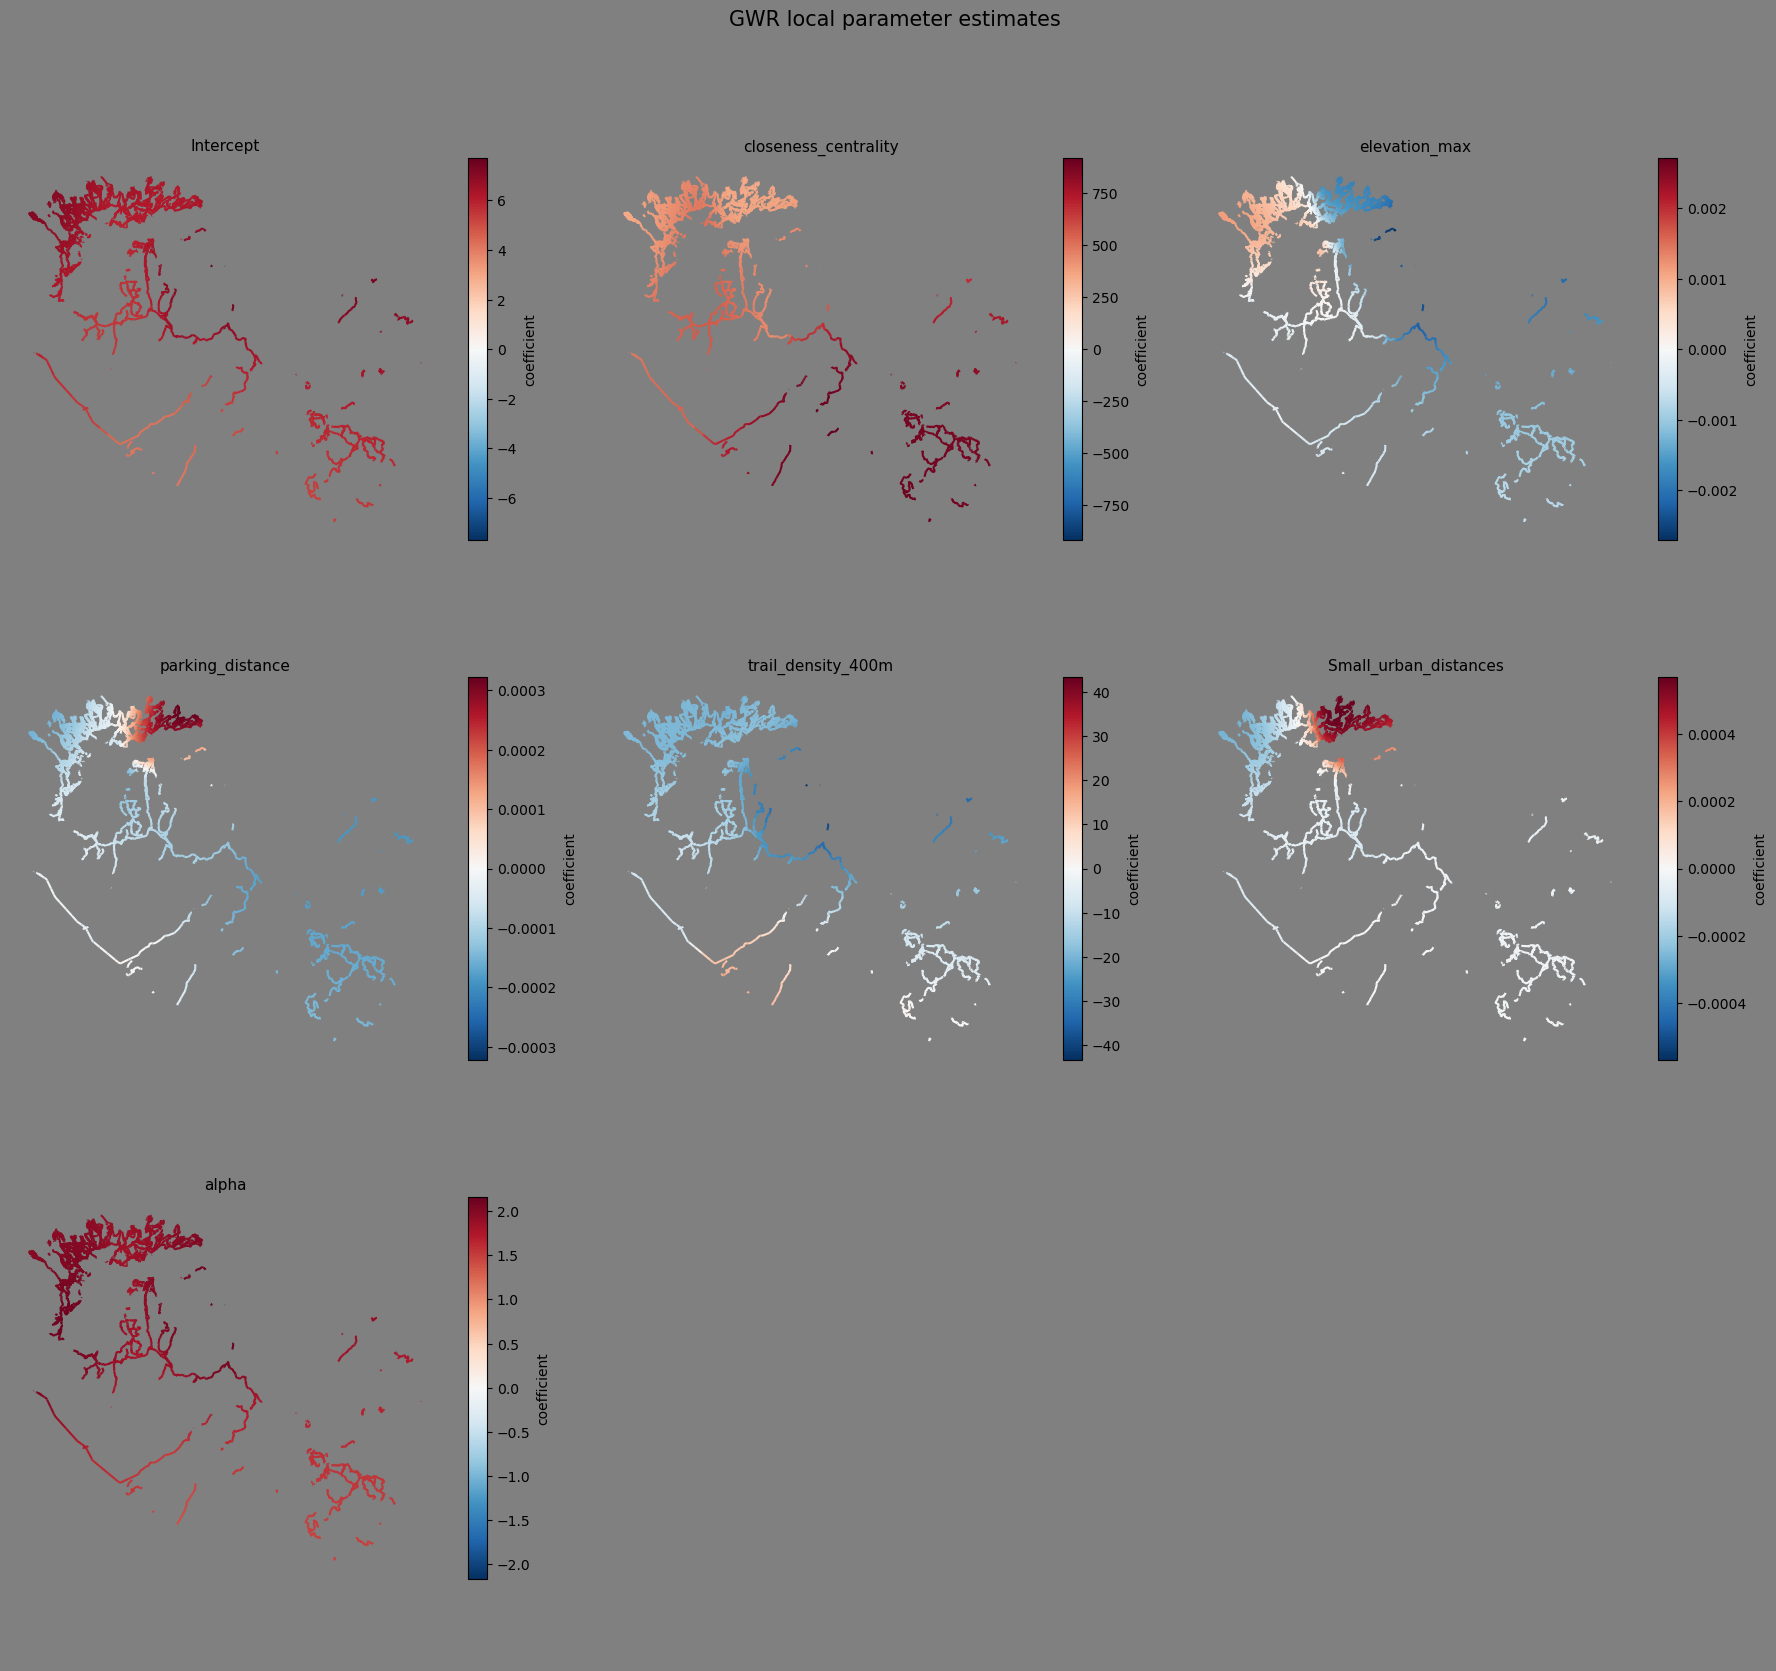

In [30]:
def plot_coefficient_grid(gdf, param_names, ncols=3, cmap="RdBu_r", markersize=8):
    n = len(param_names)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5.5 * nrows))
    axes = np.atleast_1d(axes).ravel()

    for i, p in enumerate(param_names):
        ax = axes[i]
        col = f"b_{p}"
        vals = gdf[col]
        vmax = np.nanmax(np.abs(vals))
        norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

        gdf.plot(
            column=col, ax=ax, cmap=cmap, norm=norm,
            markersize=markersize, legend=True,
            legend_kwds={"shrink": 0.7, "label": "coefficient"},
        )
        ax.set_title(p, fontsize=11)
        ax.set_axis_off()

    for j in range(n, len(axes)):
        axes[j].set_axis_off()

    fig.suptitle("GWR local parameter estimates", fontsize=15, y=1.01)
    fig.tight_layout()
    return fig

fig1 = plot_coefficient_grid(gdf, param_names)
plt.show()


### Significance (pseudo t-values)

`t = b / se`. Values with `|t| < 1.96` are (approximately) not significant at the 95% level and are
shown hatched/greyed out on each map so the significant "hotspots" of each relationship stand out.


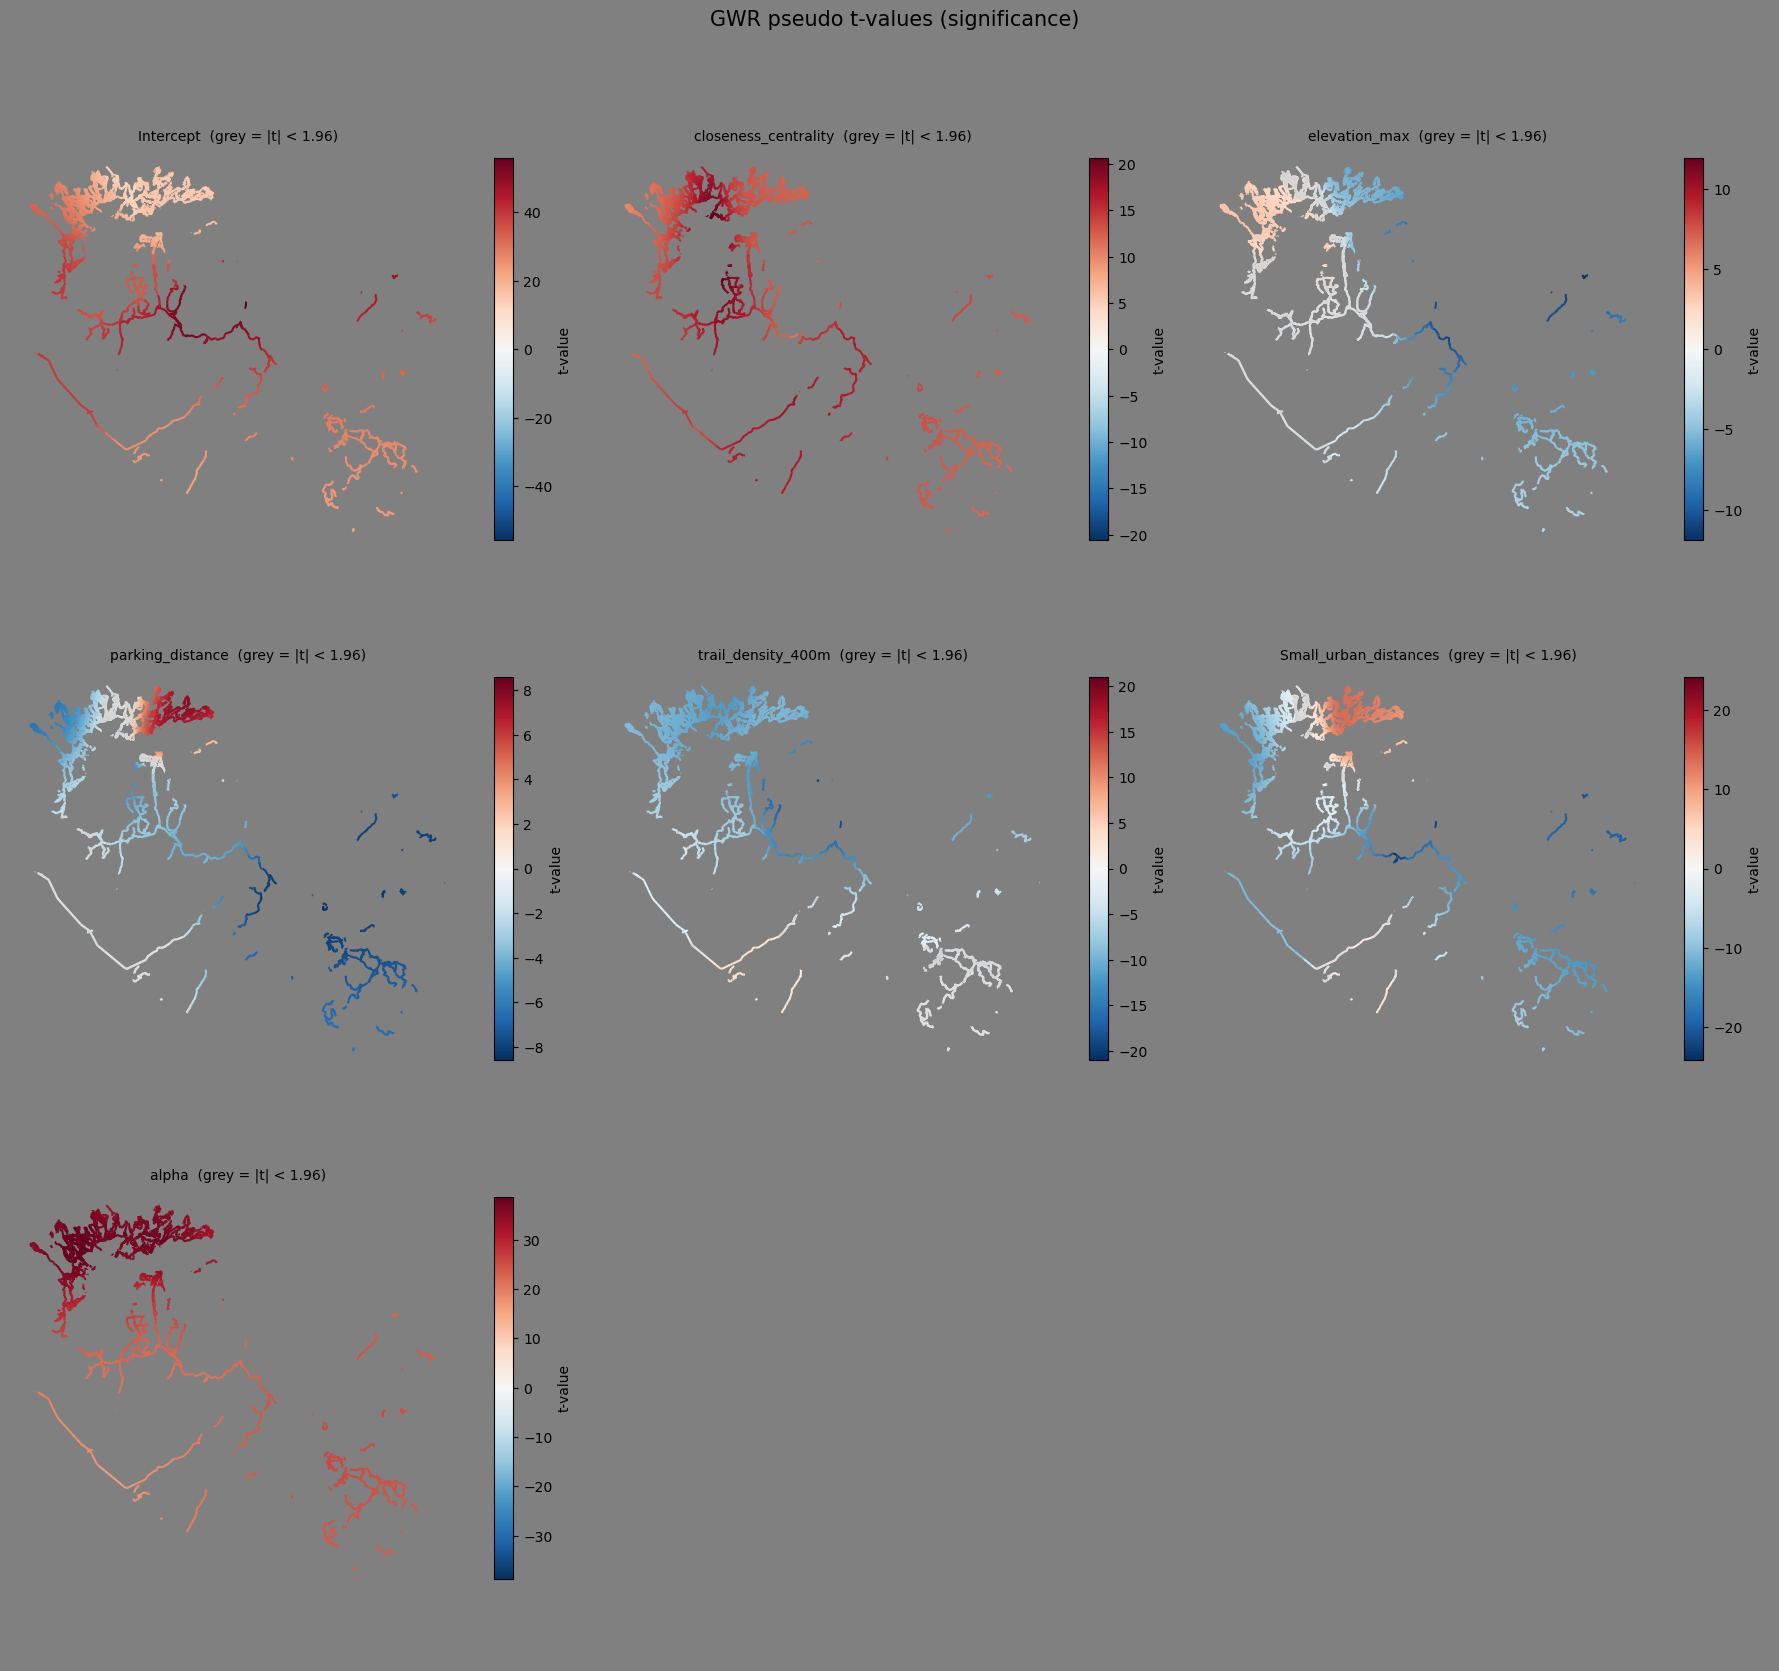

In [32]:
def plot_tvalue_grid(gdf, param_names, ncols=3, cmap="RdBu_r", markersize=8, crit_t=1.96):
    n = len(param_names)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5.5 * nrows))
    axes = np.atleast_1d(axes).ravel()

    for i, p in enumerate(param_names):
        ax = axes[i]
        b_col, se_col = f"b_{p}", f"se_{p}"
        t = gdf[b_col] / gdf[se_col]
        tmax = np.nanmax(np.abs(t))
        norm = TwoSlopeNorm(vmin=-tmax, vcenter=0, vmax=tmax)

        gdf.assign(_t=t).plot(
            column="_t", ax=ax, cmap=cmap, norm=norm,
            markersize=markersize, legend=True,
            legend_kwds={"shrink": 0.7, "label": "t-value"},
        )

        # overlay non-significant points in light grey
        not_sig = gdf[np.abs(t) < crit_t]
        if len(not_sig):
            not_sig.plot(ax=ax, color="lightgrey", markersize=markersize, alpha=0.6)

        ax.set_title(f"{p}  (grey = |t| < {crit_t})", fontsize=10)
        ax.set_axis_off()

    for j in range(n, len(axes)):
        axes[j].set_axis_off()

    fig.suptitle("GWR pseudo t-values (significance)", fontsize=15, y=1.01)
    fig.tight_layout()
    return fig

fig2 = plot_tvalue_grid(gdf, param_names)
plt.show()


## 2. Local R²

Spatial variation in how well the model fits at each location.


In [21]:
def get_local_r2(gdf, results):
    ## 1) plain dict export with a localR2-style key
    for key in ["localR2", "local_R2", "localr2", "local_r2"]:
        if isinstance(results, dict) and key in results:
            arr = np.asarray(results[key]).squeeze()
            if arr.shape[0] == len(gdf):
                return arr, "results object"

    ## 2) fitted GWRResults object (not a dict) exposing .localR2 directly
    if hasattr(results, "localR2"):
        arr = np.asarray(results.localR2).squeeze()
        if arr.shape[0] == len(gdf):
            return arr, "results.localR2 attribute"

    return None, None

local_r2, source = get_local_r2(gdf, results)

if local_r2 is None:
    print("No 'localR2' found in the results object — falling back to a manual adaptive-neighbourhood "
          "approximation using the fitted bandwidth. Replace this with the real mgwr localR2 if you have it.")

    bw = results["general_bandwidth"][0] if isinstance(results, dict) else results.bw
    # Use centroids so this also works for polygon/line geometries, not just points.
    # Centroids on a geographic (lat/lon) CRS are inaccurate for distance-based neighbour search,
    # so reproject to the data's own projected CRS first if needed.
    if gdf.crs is not None and gdf.crs.is_geographic:
        print(f"CRS {gdf.crs} is geographic — reprojecting to its UTM equivalent for centroid/distance calcs.")
        gdf_proj = gdf.to_crs(gdf.estimate_utm_crs())
    else:
        gdf_proj = gdf
    centroids = gdf_proj.geometry.centroid
    coords = np.column_stack([centroids.x, centroids.y])
    y = gdf["Y"].to_numpy(dtype=float)
    yhat = gdf["yhat"].to_numpy(dtype=float)

    tree = cKDTree(coords)
    k = int(min(max(bw, 20), len(gdf)))  # neighbourhood size capped to dataset size
    _, idx = tree.query(coords, k=k)

    local_r2 = np.empty(len(gdf))
    for i in range(len(gdf)):
        nbrs = idx[i]
        y_local = y[nbrs]
        yhat_local = yhat[nbrs]
        ss_res = np.sum((y_local - yhat_local) ** 2)
        ss_tot = np.sum((y_local - y_local.mean()) ** 2)
        local_r2[i] = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    source = f"manual approximation (k={k} nearest neighbours)"

gdf["_local_r2"] = local_r2
print(f"Local R2 source: {source}")
print(gdf["_local_r2"].describe())


No 'localR2' found in the results object — falling back to a manual adaptive-neighbourhood approximation using the fitted bandwidth. Replace this with the real mgwr localR2 if you have it.
Local R2 source: manual approximation (k=3634 nearest neighbours)
count    5130.000000
mean        0.115363
std         0.026676
min         0.094653
25%         0.099533
50%         0.106163
75%         0.108276
max         0.182284
Name: _local_r2, dtype: float64


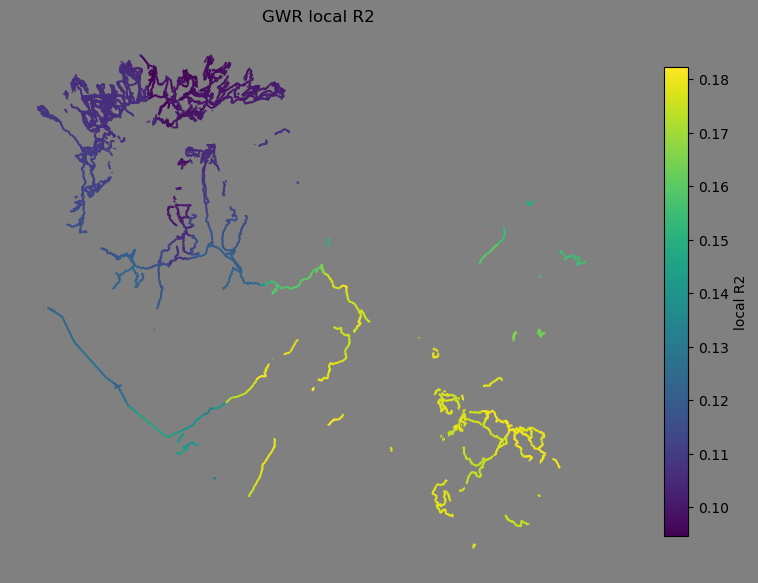

In [33]:
fig, ax = plt.subplots(figsize=(8, 7))
gdf.plot(
    column="_local_r2", ax=ax, cmap="viridis",
    markersize=10, legend=True,
    legend_kwds={"shrink": 0.7, "label": "local R2"},
)
ax.set_title("GWR local R2")
ax.set_axis_off()
plt.tight_layout()
plt.show()


## 3. Standardised local (GWR) residuals

The `res` column is `Y - yhat` from the GWR model. Standardising (z-score) puts residuals on a
comparable scale so unusually large over/under-predictions stand out regardless of the raw
magnitude of `Y` at that location.


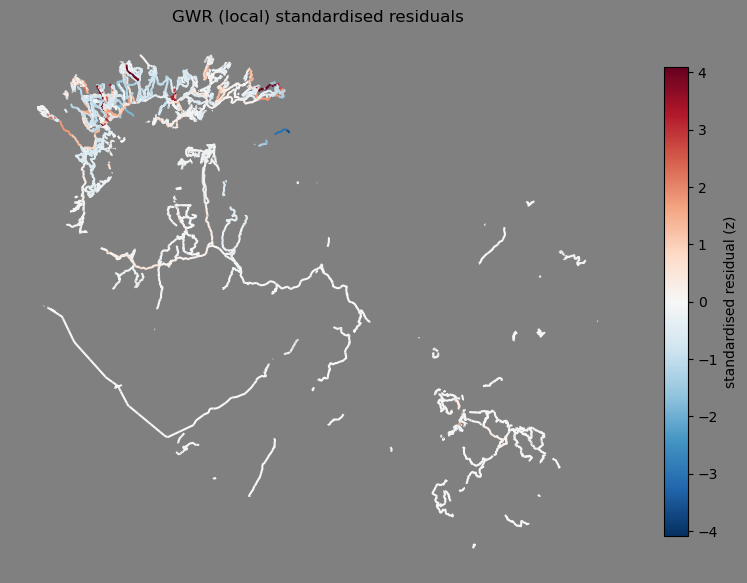

In [34]:
gdf["res_std"] = (gdf["res"] - gdf["res"].mean()) / gdf["res"].std()

fig, ax = plt.subplots(figsize=(8, 7))
vmax = np.nanmax(np.abs(gdf["res_std"]))/3
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

gdf.plot(
    column="res_std", ax=ax, cmap="RdBu_r", norm=norm,
    markersize=10, legend=True,
    legend_kwds={"shrink": 0.7, "label": "standardised residual (z)"},
)
ax.set_title("GWR (local) standardised residuals")
ax.set_axis_off()
plt.tight_layout()
plt.show()


## 4. Standardised global residuals (comparison)

To see what the GWR is buying you over a plain global model, we fit an OLS using the same
explanatory variables (the ones with `b_*`/`se_*` pairs, excluding the dispersion parameter
`alpha` if present) on the whole dataset, then standardise *those* residuals the same way.
Comparing this map to the local-residual map above shows where allowing coefficients to vary
spatially actually improved the fit.


In [25]:
import statsmodels.api as sm

global_predictors = [p for p in param_names if p.lower() not in ("alpha", "intercept")]
X = gdf[global_predictors].astype(float)
X = sm.add_constant(X)
y = gdf["Y"].astype(float)

global_model = sm.OLS(y, X, missing="drop").fit()
print(global_model.summary())

gdf["yhat_global"] = global_model.predict(X)
gdf["res_global"] = gdf["Y"] - gdf["yhat_global"]
gdf["res_global_std"] = (gdf["res_global"] - gdf["res_global"].mean()) / gdf["res_global"].std()

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.072
Model:                            OLS   Adj. R-squared:                  0.071
Method:                 Least Squares   F-statistic:                     79.63
Date:                Wed, 26 Aug 2026   Prob (F-statistic):           1.05e-80
Time:                        23:14:34   Log-Likelihood:                -46771.
No. Observations:                5130   AIC:                         9.355e+04
Df Residuals:                    5124   BIC:                         9.359e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                   869.88

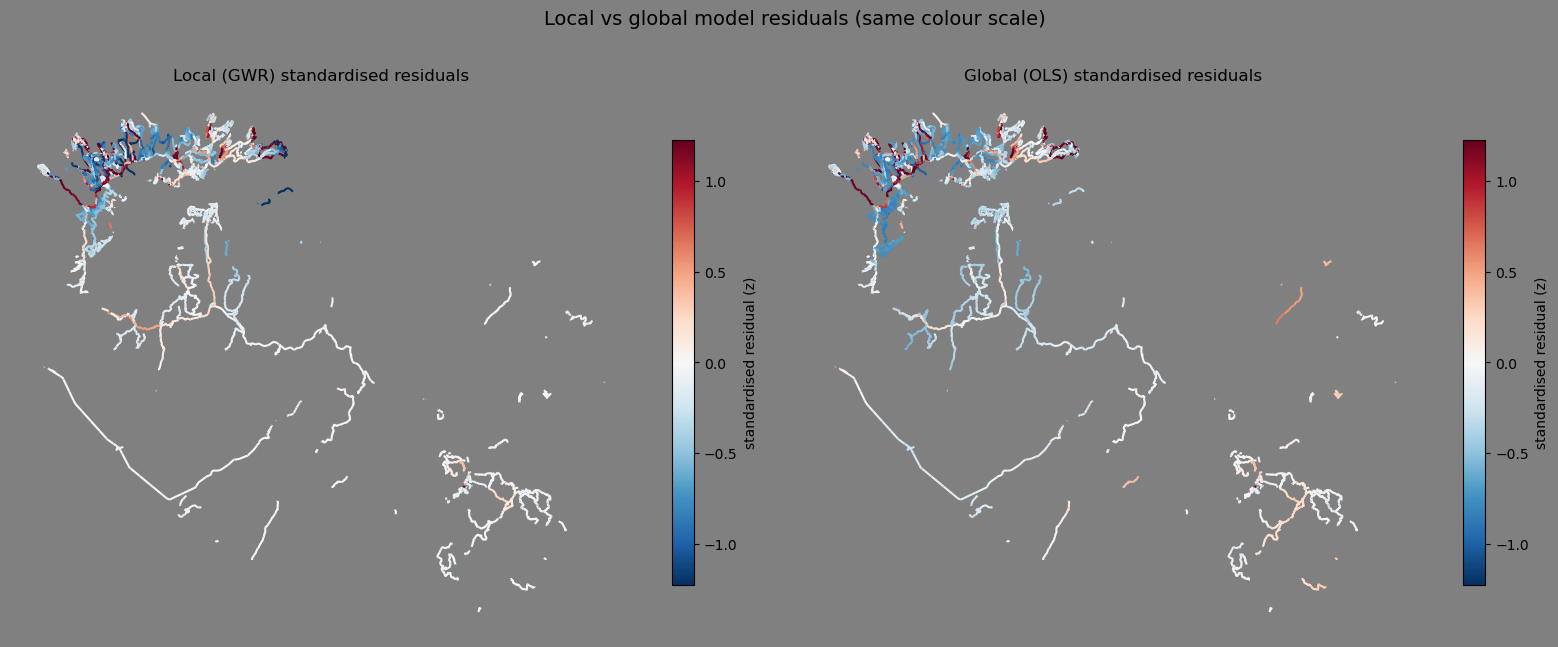

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

vmax = max(
    np.nanmax(np.abs(gdf["res_std"])),
    np.nanmax(np.abs(gdf["res_global_std"])),
)/10
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

gdf.plot(column="res_std", ax=axes[0], cmap="RdBu_r", norm=norm, markersize=10,
         legend=True, legend_kwds={"shrink": 0.7, "label": "standardised residual (z)"})
axes[0].set_title("Local (GWR) standardised residuals")
axes[0].set_axis_off()

gdf.plot(column="res_global_std", ax=axes[1], cmap="RdBu_r", norm=norm, markersize=10,
         legend=True, legend_kwds={"shrink": 0.7, "label": "standardised residual (z)"})
axes[1].set_title("Global (OLS) standardised residuals")
axes[1].set_axis_off()

fig.suptitle("Local vs global model residuals (same colour scale)", fontsize=14)
fig.tight_layout()
plt.show()


## Model fit summary

Pulls the headline diagnostics (deviance, log-likelihood, pseudo-R², AIC, AICc) out of `measures`
and `global_measures` for a side-by-side comparison, plus the effective number of parameters
(`ENP`) per term and the fitted bandwidth.


In [38]:
def measures_to_series(measures_da):
    return pd.Series(np.asarray(measures_da), index=[str(x) for x in measures_da['dim_0'].values])

if isinstance(results, dict):
    bw = results.get("general_bandwidth")
    print("Bandwidth:", bw)

    if "measures" in results and "global_measures" in results:
        comp = pd.DataFrame({
            "GWR": measures_to_series(results["measures"]),
            "Global": measures_to_series(results["global_measures"]),
        })
        display(comp)

    if "ENP" in results:
        enp = measures_to_series(results["ENP"]) if hasattr(results["ENP"], "coords") else pd.Series(results["ENP"])
        print("\nEffective number of parameters per term:")
        display(enp)


Bandwidth: [3634.]


,GWR,Global
AIC,74764.788418,NaN
AICc,74764.992472,NaN
adjpctdev,0.292817,NaN
adjpctdevg,NaN,0.174233
deviance,6014.253355,6497.228703
full_Log_likelihood,-37360.062907,NaN
pctdev,0.295758,NaN
pctdevg,NaN,0.175038



Effective number of parameters per term:


Intercept                19.141116
closeness_centrality     19.141116
elevation_max            19.141116
parking_distance         19.141116
trail_density_400m       19.141116
Small_urban_distances    19.141116
MGWR                     19.141116
GWR                      19.141116
alpha                     3.190186
dtype: float64